--- California Housing Preview ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


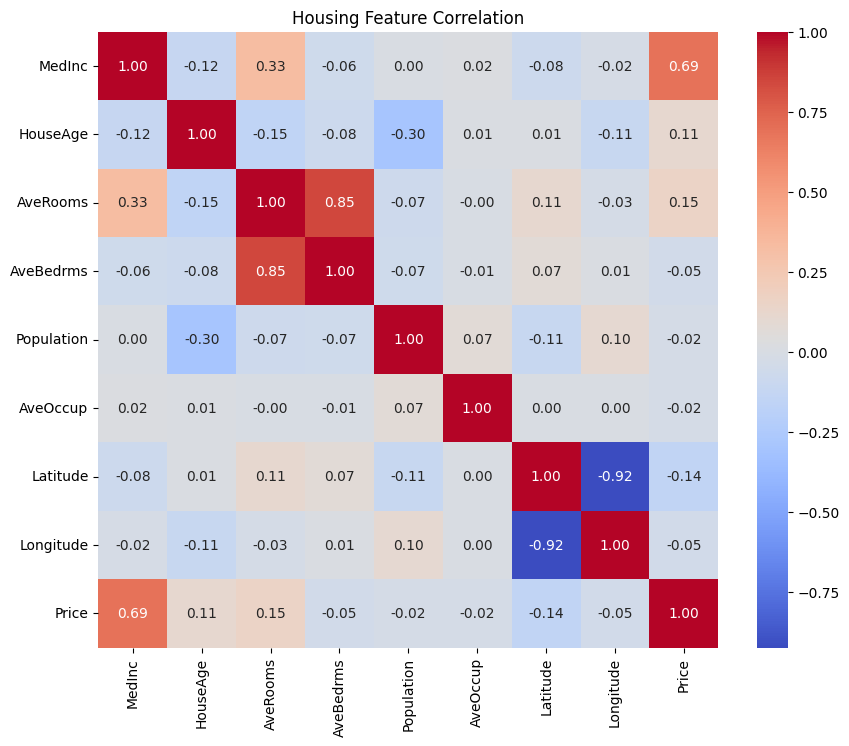


--- Model Performance ---
R² Score (Accuracy): 0.81
Mean Absolute Error: $32754.26


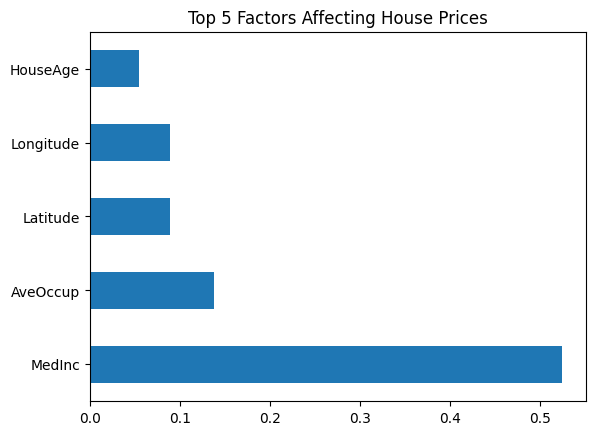

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. LOAD DATASET
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data['Price'] = housing.target # Price is in units of $100,000

# 2. DATA EXPLORATION
print("--- California Housing Preview ---")
print(data.head())

# Heatmap to see which features (like MedInc - Median Income) impact price most
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Housing Feature Correlation')
plt.show()

# 3. PREPARING DATA
X = data.drop('Price', axis=1)
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. MODEL BUILDING (Using Random Forest for better accuracy)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. EVALUATION
predictions = model.predict(X_test)
print("\n--- Model Performance ---")
print(f"R² Score (Accuracy): {r2_score(y_test, predictions):.2f}")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, predictions) * 100000:.2f}")

# 6. VISUALIZING IMPORTANT FEATURES
# This shows recruiters you understand what drives the model
importances = pd.Series(model.feature_importances_, index=housing.feature_names)
importances.nlargest(5).plot(kind='barh')
plt.title('Top 5 Factors Affecting House Prices')
plt.show()